# Lecture 04 — Course-selection patterns

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Association rule mining · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Explore co-enrolment patterns in a fictional programme dataset.

## Practical problem
An academic department wants to see which optional courses students commonly select together.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** Course choices are fabricated. No rule should automatically restrict academic advising or eligibility.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 660 rows × 9 columns


,ai,python,statistics,cybersecurity,databases,business_analytics,research_methods,cloud,transaction_id
0,0,0,0,1,1,0,1,1,1
1,0,0,0,0,1,0,1,1,2
2,0,1,1,0,0,0,0,0,3
3,0,0,1,1,0,1,1,0,4
4,0,0,1,0,0,1,1,0,5


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['ai', 'python', 'statistics', 'cybersecurity', 'databases', 'business_analytics', 'research_methods', 'cloud', 'transaction_id']
Missing values per column:
ai                    0
python                0
statistics            0
cybersecurity         0
databases             0
business_analytics    0
research_methods      0
cloud                 0
transaction_id        0


## 2. Visualise purchase patterns
Transactions are represented by zeros and ones: 1 means the item was observed in the basket. No product is a supervised class label.

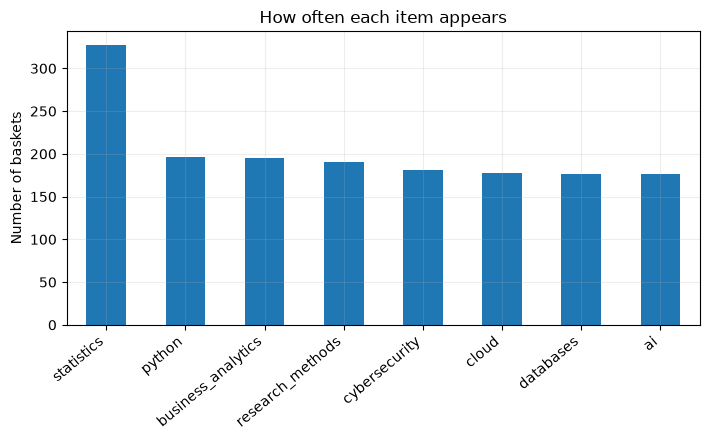

Example baskets:
1 ['cybersecurity', 'databases', 'research_methods', 'cloud']
2 ['databases', 'research_methods', 'cloud']
3 ['python', 'statistics']
4 ['statistics', 'cybersecurity', 'business_analytics', 'research_methods']
5 ['statistics', 'business_analytics', 'research_methods']


In [3]:
items=[c for c in df.columns if c!='transaction_id']
counts=df[items].sum().sort_values(ascending=False)
counts.plot.bar(title='How often each item appears',ylabel='Number of baskets');plt.xticks(rotation=40,ha='right');plt.tight_layout();plt.show()
print('Example baskets:')
for _,r in df.head(5).iterrows():
 print(int(r['transaction_id']),[i for i in items if r[i]==1])

## 3. Derive association rules (one antecedent item → one consequent item)
**Support** = proportion of all baskets containing both items. **Confidence** = proportion containing B among baskets containing A. **Lift** = confidence divided by the overall frequency of B; lift above 1 indicates positive association. Association rules are descriptive; they do not prove causation.

In [4]:
from itertools import permutations
items=[c for c in df.columns if c!='transaction_id']
N=len(df)
# Simple pedagogical implementation of one-item => one-item association rules.
rows=[]
for left,right in permutations(items,2):
    pa=df[left].mean();pb=df[right].mean()
    pab=((df[left]==1)&(df[right]==1)).mean()
    if pa==0 or pb==0: continue
    confidence=pab/pa
    lift=confidence/pb
    rows.append({'if_bought':left,'then_recommend':right,'support':pab,'confidence':confidence,'lift':lift})
rules=pd.DataFrame(rows)
strong=rules.query('support >= .10 and confidence >= .30').sort_values(['lift','confidence'],ascending=False)
print(f'{len(strong)} filtered rules from {N} orders')
display(strong.head(12).round(3))

18 filtered rules from 660 orders


,if_bought,then_recommend,support,confidence,lift
31,databases,cybersecurity,0.155,0.576,2.101
24,cybersecurity,databases,0.155,0.564,2.101
52,cloud,cybersecurity,0.155,0.573,2.090
27,cybersecurity,cloud,0.155,0.564,2.090
34,databases,cloud,0.145,0.542,2.011
53,cloud,databases,0.145,0.539,2.011
7,python,ai,0.159,0.536,2.009
0,ai,python,0.159,0.597,2.009
47,research_methods,business_analytics,0.170,0.589,1.995
40,business_analytics,research_methods,0.170,0.574,1.995


## 4. Plot the discovered rules
A strong rule should have useful support as well as lift: an apparently enormous lift from a very rare combination may not generalise.

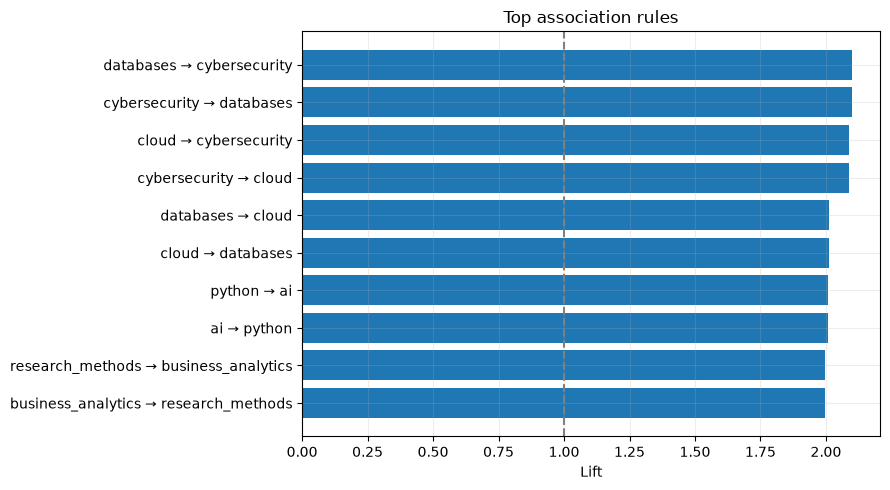

In [5]:
top=strong.head(10).copy()
if top.empty: top=rules.sort_values('lift',ascending=False).head(10)
top['rule']=top['if_bought']+' → '+top['then_recommend']
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(top['rule'].iloc[::-1],top['lift'].iloc[::-1]);ax.axvline(1,linestyle='--',color='gray')
ax.set(xlabel='Lift',title='Top association rules');plt.tight_layout();plt.show()

## 5. Make a rule-based suggestion for a new basket
This is an association-rule recommender: the recommendation is the consequent of the strongest matching rule, not a trained classification label. Consumers have different needs; co-purchases are not necessarily preferences.

In [6]:
cart=['ai']
options=strong[(strong['if_bought'].isin(cart)) & (~strong['then_recommend'].isin(cart))].copy()
print('Current basket:',cart)
if len(options):
 best=options.iloc[0]
 print(f"Suggested item: {best['then_recommend']} (confidence={best['confidence']:.1%}, lift={best['lift']:.2f})")
else: print('No suitable rule at the chosen support/confidence threshold.')

Current basket: ['ai']
Suggested item: python (confidence=59.7%, lift=2.01)


## 6. Evaluation appropriate to association rules
Report **support, confidence, and lift**, and optionally validate held-out baskets. **Accuracy, precision, recall and confusion matrices** are not the general measures for an unsupervised association-rule discovery task; they would require defining a separate prediction target and evaluation protocol.

## Student investigation and discussion
1. Why does co-enrolment not imply a prerequisite?
2. How might compulsory modules create spurious rules?
3. What would be an ethical way to use course associations?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.